In [12]:
import os

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from sklearn.metrics.pairwise import cosine_similarity
from functools import reduce

In [2]:
spark = SparkSession.builder.master("local[*]").getOrCreate()

spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")

In [3]:
# Read the files
logs_df = spark.read.parquet("/mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_*.parquet")
ships_df = spark.read.parquet("/mnt/data/public/noaa-ais/2023_NOAA_AIS_ships_*.parquet")

# Checking for Null Values

In [4]:
import glob

log_paths = sorted(
    p for p in glob.glob("/mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_*.parquet")
    if "_04.parquet" not in p
)

ship_paths = sorted(
    glob.glob("/mnt/data/public/noaa-ais/2023_NOAA_AIS_ships_*.parquet")
)

# This now excludes April
logs_df1 = spark.read.parquet(*log_paths)
ships_df1 = spark.read.parquet(*ship_paths)

In [5]:
def count_selected_nulls(paths, file_type):
    """
    For each parquet in `paths`:
      - derive Hour from BaseDateTime if possible
      - count nulls ONLY for the variables that actually exist in that file
        among: VesselType, SOG, LAT, LON, Month, Hour
    """
    cols_interest = ["VesselType", "SOG", "LAT", "LON", "Month", "Hour"]
    results = []

    for path in paths:
        print(f"Processing {file_type.upper()} file: {path}")
        df = spark.read.parquet(path)

        # derive Hour from BaseDateTime if it exists
        if "BaseDateTime" in df.columns:
            df = df.withColumn(
                "Hour",
                F.hour(
                    F.to_timestamp(
                        (F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")
                    )
                )
            )

        # choose only columns that actually exist in this file
        available = [c for c in cols_interest if c in df.columns]
        if not available:
            continue

        null_row = df.select([
            F.sum(F.col(c).isNull().cast("int")).alias(c)
            for c in available
        ]).first()

        row = {
            "file": os.path.basename(path),
            "type": file_type,
        }
        for c in available:
            row[f"{c}_nulls"] = int(null_row[c])
        row["total_nulls"] = sum(row[f"{c}_nulls"] for c in available)

        results.append(row)

    return pd.DataFrame(results).sort_values(["type", "file"])

In [6]:
logs_summary  = count_selected_nulls(log_paths,  "log")
ships_summary = count_selected_nulls(ship_paths, "ship")

print("\n=== LOG FILES ===")
print(logs_summary)

print("\n=== SHIP FILES ===")
print(ships_summary)

Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_01.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_02.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_03.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_05.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_06.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_07.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_08.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_09.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_10.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_11.parquet
Processing LOG file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_12.parquet
Processing SHIP file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_ships_01.parquet
Processing SHIP file: /mnt/data/public/noaa-ais/2023_NOAA_AIS_ships_02.par

To handle the null values, it was replaced with 0 (to signify the type is "Unknown") to preserve AIS movement data

In [6]:
from functools import reduce

cleaned_ship_dfs = []

for path in ship_paths:
    file_name = os.path.basename(path)
    print(f"Cleaning {file_name}...")
    
    df = spark.read.parquet(path)

    df_clean = df.withColumn(
        "VesselTypeLabel",
        F.when(F.col("VesselType").isNull(), F.lit("Unknown"))
         .otherwise(F.col("VesselType").cast("string"))
    )

    cleaned_ship_dfs.append(df_clean)

# combine all cleaned ship data into one DF in memory
cleaned_ships = reduce(lambda a, b: a.unionByName(b), cleaned_ship_dfs)
cleaned_ships = cleaned_ships.cache()

# quick sanity check
cleaned_ships.select("MMSI", "VesselType", "VesselTypeLabel").show(5, truncate=False)


Cleaning 2023_NOAA_AIS_ships_01.parquet...
Cleaning 2023_NOAA_AIS_ships_02.parquet...
Cleaning 2023_NOAA_AIS_ships_03.parquet...
Cleaning 2023_NOAA_AIS_ships_04.parquet...
Cleaning 2023_NOAA_AIS_ships_05.parquet...
Cleaning 2023_NOAA_AIS_ships_06.parquet...
Cleaning 2023_NOAA_AIS_ships_07.parquet...
Cleaning 2023_NOAA_AIS_ships_08.parquet...
Cleaning 2023_NOAA_AIS_ships_09.parquet...
Cleaning 2023_NOAA_AIS_ships_10.parquet...
Cleaning 2023_NOAA_AIS_ships_11.parquet...
Cleaning 2023_NOAA_AIS_ships_12.parquet...
+------+----------+---------------+
|MMSI  |VesselType|VesselTypeLabel|
+------+----------+---------------+
|0     |0.0       |0.0            |
|1     |60.0      |60.0           |
|11    |90.0      |90.0           |
|111   |90.0      |90.0           |
|368926|35.0      |35.0           |
+------+----------+---------------+
only showing top 5 rows



In [29]:
from pyspark.sql import functions as F
import os

def get_shapes(parquet_paths):
    results = []
    
    for path in parquet_paths:
        df = spark.read.parquet(path)
        row_count = df.count()
        col_count = len(df.columns)

        results.append({
            "file": os.path.basename(path),
            "rows": row_count,
            "columns": col_count
        })

    return pd.DataFrame(results)

log_shapes = get_shapes(log_paths1)
ship_shapes = get_shapes(ship_paths1)

print("LOG FILE SHAPES:")
display(log_shapes)

print("\nSHIP FILE SHAPES:")
display(ship_shapes)

LOG FILE SHAPES:


,file,rows,columns
0,2023_NOAA_AIS_logs_01.parquet,242779878,7
1,2023_NOAA_AIS_logs_02.parquet,207511685,7
2,2023_NOAA_AIS_logs_03.parquet,240181840,7
3,2023_NOAA_AIS_logs_05.parquet,264576611,7
4,2023_NOAA_AIS_logs_06.parquet,265050440,7
5,2023_NOAA_AIS_logs_07.parquet,300328004,7
6,2023_NOAA_AIS_logs_08.parquet,279393257,7
7,2023_NOAA_AIS_logs_09.parquet,263577992,7
8,2023_NOAA_AIS_logs_10.parquet,250684809,7
9,2023_NOAA_AIS_logs_11.parquet,224705899,7



SHIP FILE SHAPES:


,file,rows,columns
0,2023_NOAA_AIS_ships_01.parquet,33716,12
1,2023_NOAA_AIS_ships_02.parquet,32435,12
2,2023_NOAA_AIS_ships_03.parquet,40523,12
3,2023_NOAA_AIS_ships_04.parquet,41515,12
4,2023_NOAA_AIS_ships_05.parquet,47779,12
5,2023_NOAA_AIS_ships_06.parquet,49045,12
6,2023_NOAA_AIS_ships_07.parquet,50721,12
7,2023_NOAA_AIS_ships_08.parquet,50152,12
8,2023_NOAA_AIS_ships_09.parquet,47954,12
9,2023_NOAA_AIS_ships_10.parquet,44955,12


# Temporal Analysis Using Line Chart

For `BaseDateTime`, it was converted from its original nanosecond timestamp into a standard timestamp type so that it can be easily interpreted, aggregated, and analyzed by time.

In [10]:
logs_df = logs_df.withColumn(
    "BaseDateTime",
    F.to_timestamp((F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")),
)

logs_df.select("BaseDateTime").show(2)

+-------------------+
|       BaseDateTime|
+-------------------+
|2023-01-01 08:00:00|
|2023-01-01 08:00:00|
+-------------------+
only showing top 2 rows



We then joined logs_df and ships_df so that we can have the cargo type.

In [11]:
logs_with_vessel = logs_df.join(
    ships_df.select("MMSI", "VesselType"),  # only need MMSI and Vessel
    on="MMSI",
    how="left",  # keep all log rows even if Vessel is missing
)

logs_with_vessel.show(2)

+---------+-------------------+--------+---------+---+-----+-------+----------+
|     MMSI|       BaseDateTime|     LAT|      LON|SOG|  COG|Heading|VesselType|
+---------+-------------------+--------+---------+---+-----+-------+----------+
|129129903|2023-01-01 08:00:00|18.81136|-66.46386|6.5|338.8|  338.0|      36.0|
|129129903|2023-01-01 08:00:00|18.81136|-66.46386|6.5|338.8|  338.0|      36.0|
+---------+-------------------+--------+---------+---+-----+-------+----------+
only showing top 2 rows



In [12]:
# Create mapping from AIS Vessel Code to Vessel Group
ais_to_group = {}

# Not Available
ais_to_group[0] = "Not Available"
ais_to_group[np.nan] = "Not Available"

# Other codes
ais_to_group.update({i: "Other" for i in range(1, 20)})
ais_to_group.update({i: "Other" for i in range(23, 30)})
ais_to_group.update({i: "Other" for i in range(33, 36)})
ais_to_group.update({i: "Other" for i in range(38, 41)})
ais_to_group.update({i: "Other" for i in range(45, 60)})
ais_to_group.update({i: "Other" for i in range(90, 1000)})  # future/regional

# Tug/Tow
ais_to_group.update(
    {21: "Tug Tow", 22: "Tug Tow", 31: "Tug Tow", 32: "Tug Tow", 52: "Tug Tow"}
)

# Fishing
ais_to_group[30] = "Fishing"

# Military
ais_to_group[35] = "Military"

# Pleasure Craft / Sailing
ais_to_group[36] = "Pleasure Craft/Sailing"
ais_to_group[37] = "Pleasure Craft/Sailing"

# Passenger
ais_to_group.update({i: "Passenger" for i in range(60, 70)})

# Cargo
ais_to_group.update({i: "Cargo" for i in range(70, 80)})

# Tanker
ais_to_group.update({i: "Tanker" for i in range(80, 90)})

## By Month

In [13]:
monthly_vessel_counts = (
    logs_with_vessel
    # truncate timestamp to the month
    .withColumn("Month", F.date_trunc("month", "BaseDateTime"))
    # group by vessel type and month
    .groupBy("VesselType", "Month")
    # count distinct ships per group
    .agg(F.countDistinct("MMSI").alias("NumShips"))
    # order by month and vessel type
    .orderBy("Month", "VesselType")
)

In [14]:
parquet_path = "data/monthly_vessel_counts.parquet"

if not os.path.exists(parquet_path):
    # Only save if the file doesn't exist
    monthly_vessel_counts.write.mode("overwrite").parquet(parquet_path)

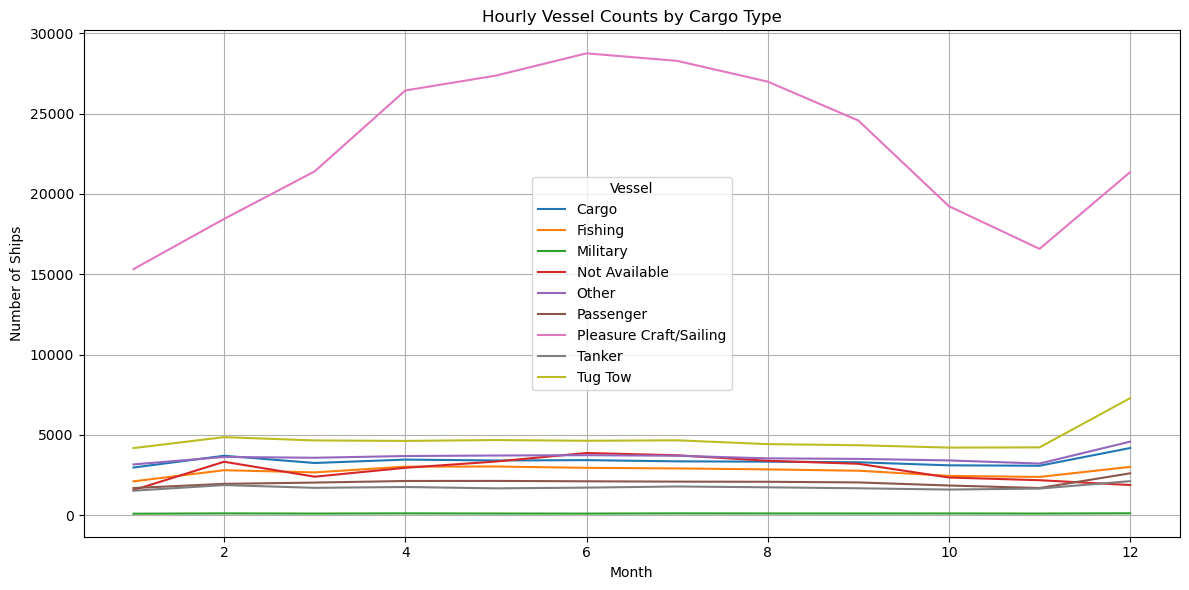

In [15]:
monthly_vessel_counts_df = pd.read_parquet(parquet_path)
monthly_vessel_counts_df["Month"] = monthly_vessel_counts_df["Month"].dt.month
monthly_vessel_counts_df["Vessel Name"] = monthly_vessel_counts_df["VesselType"].map(
    ais_to_group
)
monthly_vessel_counts_agg = monthly_vessel_counts_df.groupby(
    ["Month", "Vessel Name"], as_index=False
)["NumShips"].sum()
monthly_vessel_counts_pivot = monthly_vessel_counts_agg.pivot(
    index="Month", columns="Vessel Name", values="NumShips"
)

plt.figure(figsize=(12, 6))
monthly_vessel_counts_pivot.plot(ax=plt.gca())

plt.xlabel("Month")
plt.ylabel("Number of Ships")
plt.title("Hourly Vessel Counts by Cargo Type")
plt.legend(title="Vessel")
plt.grid(True)
plt.tight_layout()
plt.show()

## By Hour

In [16]:
hourly_vessel_counts = (
    # truncate timestamp to the hour
    logs_with_vessel.withColumn("Hour", F.date_trunc("hour", "BaseDateTime"))
    # remove repeated logs for the same ship in the same hour
    .dropDuplicates(["MMSI", "Hour"])
    # group by vessel type and hour
    .groupBy("VesselType", "Hour")
    # count unique ships per group
    .agg(F.count("MMSI").alias("NumShips"))
    # order by time and vessel
    .orderBy("Hour", "VesselType")
)

In [17]:
parquet_path = "data/hourlies_cargo_counts.parquet"

if not os.path.exists(parquet_path):
    # Only save if the file doesn't exist
    hourly_vessel_counts.write.mode("overwrite").parquet(parquet_path)

We create a mapping from AIS Vessel Code to Vessel Group based on the [Marine Cadastre Project (2018)](https://coast.noaa.gov/data/marinecadastre/ais/VesselTypeCodes2018.pdf).


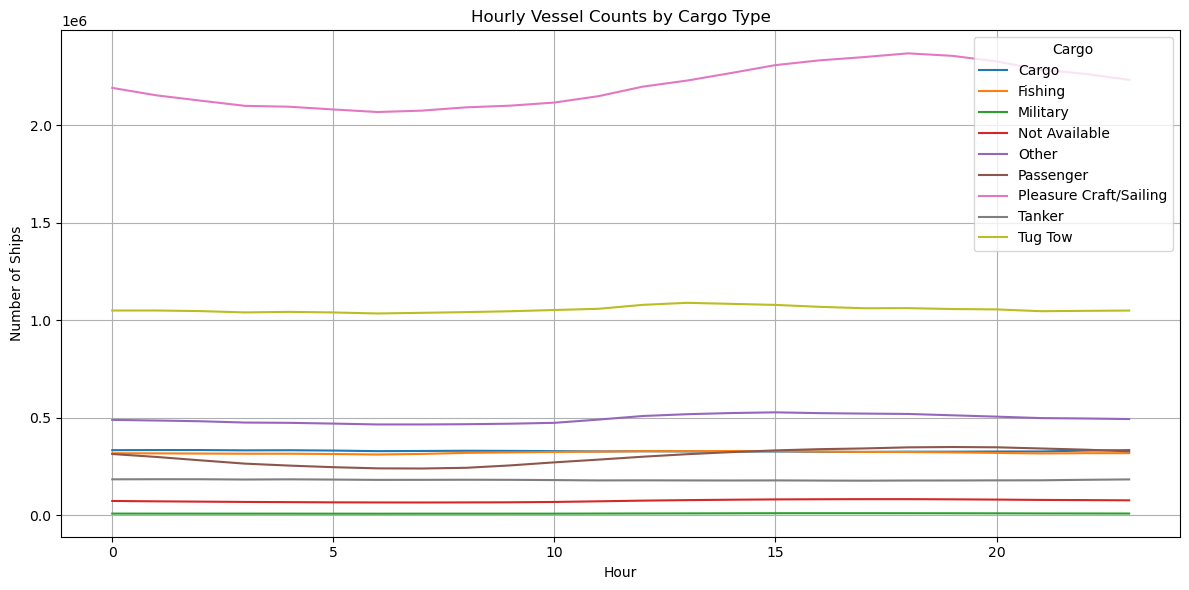

In [18]:
hourly_cargo_counts_df = pd.read_parquet(parquet_path)
hourly_cargo_counts_df["Hour"] = hourly_cargo_counts_df["Hour"].dt.hour
hourly_cargo_counts_df["Vessel Name"] = hourly_cargo_counts_df["VesselType"].map(
    ais_to_group
)
hourly_cargo_counts_agg = hourly_cargo_counts_df.groupby(
    ["Hour", "Vessel Name"], as_index=False
)["NumShips"].sum()
hourly_cargo_counts_pivot = hourly_cargo_counts_agg.pivot(
    index="Hour", columns="Vessel Name", values="NumShips"
)

plt.figure(figsize=(12, 6))
hourly_cargo_counts_pivot.plot(ax=plt.gca())

plt.xlabel("Hour")
plt.ylabel("Number of Ships")
plt.title("Hourly Vessel Counts by Cargo Type")
plt.legend(title="Cargo")
plt.grid(True)
plt.tight_layout()
plt.show()

# Vessel Type Traffic Dominance Using Bar Charts

In [19]:
# Compute monthly totals per vessel
monthly_totals = (
    monthly_vessel_counts_df.groupby(["Month", "Vessel Name"])["NumShips"]
    .sum()
    .reset_index()
)

# Compute total ships per month
month_totals = monthly_totals.groupby("Month")["NumShips"].transform("sum")

# Compute percentage per vessel per month
monthly_totals["Percentage"] = monthly_totals["NumShips"] / month_totals * 100

# Pivot: rows = Vessel Name, columns = Month, values = Percentage
monthly_percentage = monthly_totals.pivot(
    index="Vessel Name", columns="Month", values="Percentage"
).fillna(
    0
)  # fill NaN with 0 if a vessel didn't appear in a month

# Compute cosine similarity between consecutive months
months = monthly_percentage.columns.tolist()
cosine_similarities = {}

for i in range(len(months)):
    month1 = months[i]
    month2 = months[(i + 1) % len(months)]  # wrap around 12 -> 1
    vec1 = monthly_percentage[month1].values.reshape(1, -1)
    vec2 = monthly_percentage[month2].values.reshape(1, -1)

    sim = cosine_similarity(vec1, vec2)[0][0]
    cosine_similarities[f"{month1}->{month2}"] = sim

# Convert results to a DataFrame for easier viewing
cosine_sim_df = pd.DataFrame(
    list(cosine_similarities.items()), columns=["Month Pair", "Cosine Similarity"]
)

cosine_sim_df

,Month Pair,Cosine Similarity
0,1->2,0.997309
1,2->3,0.995802
2,3->4,0.998585
3,4->5,0.999897
4,5->6,0.999818
5,6->7,0.999984
6,7->8,0.999961
7,8->9,0.999774
8,9->10,0.998252
9,10->11,0.998958


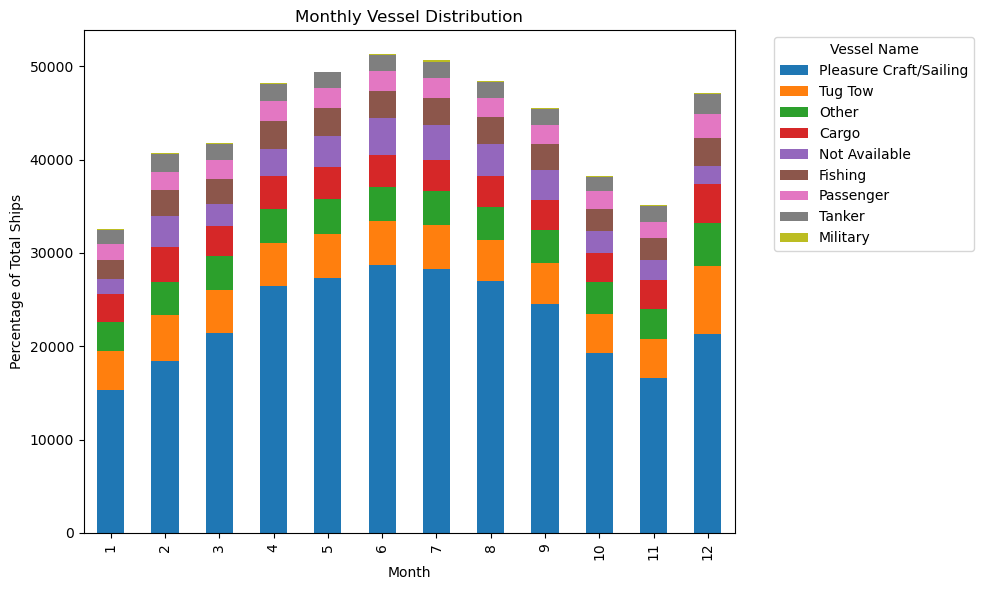

In [20]:
# Pivot the data
monthly_pivot = monthly_totals.pivot(
    index="Month", columns="Vessel Name", values="NumShips"
).fillna(0)

# Sort vessel types by their overall average (largest at bottom)
vessel_order = monthly_pivot.mean().sort_values(ascending=False).index
monthly_pivot = monthly_pivot[vessel_order]

# Plot stacked bar chart
monthly_pivot.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Monthly Vessel Distribution")
plt.xlabel("Month")
plt.ylabel("Percentage of Total Ships")
plt.legend(title="Vessel Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Speed (`SOG`) to Activity Relationship Using Scatterplots

In [21]:
ships_df.describe(['Length', 'Width']).show()

+-------+-----------------+------------------+
|summary|           Length|             Width|
+-------+-----------------+------------------+
|  count|           455496|            404242|
|   mean|45.13784094701161| 9.657964783471288|
| stddev|73.02293616288846|11.061397739623729|
|    min|              0.0|               0.0|
|    max|           1022.0|             126.0|
+-------+-----------------+------------------+



In [ ]:
# Use logs_df for ships (we needed a temp variable to do .limit(1000))
parquet_dir = "/mnt/data/public/noaa-ais/"

# List all 2023 Parquet files except the corrupted one
files_to_read = [
    os.path.join(parquet_dir, f)
    for f in os.listdir(parquet_dir)
    if f.startswith("2023_NOAA_AIS_logs") and f != "2023_NOAA_AIS_logs_04.parquet"
]

logs_skipped_04_df = spark.read.parquet(*files_to_read)

logs_skipped_04_df = logs_skipped_04_df.withColumn(
    "BaseDateTime",
    F.to_timestamp((F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")),
)

ships = logs_skipped_04_df

# Round timestamp to nearest minute
ships = ships.withColumn("Minute", F.date_trunc("minute", F.col("BaseDateTime")))

# Delta for latitude/longitude bounds (of around 5 km)
delta = 0.05

# Self-join using LAT/LON bounds to find nearby ships
nearby = ships.alias("a").join(
    ships.alias("b"),
    (F.col("a.Minute") == F.col("b.Minute"))  # same minute
    & (F.col("a.MMSI") != F.col("b.MMSI"))    # different ships
    & (F.col("b.LAT").between(F.col("a.LAT") - delta, F.col("a.LAT") + delta))
    & (F.col("b.LON").between(F.col("a.LON") - delta, F.col("a.LON") + delta))
)

# Count nearby ships per vessel per minute
nearby_count = nearby.groupBy("a.MMSI", "a.Minute").agg(
    F.countDistinct("b.MMSI").alias("num_nearby_ships")
)

# Join nearby ship counts back to original dataframe
ships_with_density = ships.join(
    nearby_count, on=["MMSI", "Minute"], how="left"
).fillna({"num_nearby_ships": 0})

# Save to parquet if the file doesn't exist
parquet_path = "data/SOG_nearby_ships.parquet"
if not os.path.exists(parquet_path):
    ships_with_density.write.mode("overwrite").parquet(parquet_path)

In [7]:
parquet_dir = "/mnt/data/public/noaa-ais/"

log_paths = sorted([
    os.path.join(parquet_dir, f)
    for f in os.listdir(parquet_dir)
    if f.startswith("2023_NOAA_AIS_logs_")
       and f != "2023_NOAA_AIS_logs_04.parquet"
])

print("Log files to use:")
for p in log_paths:
    print("  ", os.path.basename(p))

Log files to use:
   2023_NOAA_AIS_logs_01.parquet
   2023_NOAA_AIS_logs_02.parquet
   2023_NOAA_AIS_logs_03.parquet
   2023_NOAA_AIS_logs_05.parquet
   2023_NOAA_AIS_logs_06.parquet
   2023_NOAA_AIS_logs_07.parquet
   2023_NOAA_AIS_logs_08.parquet
   2023_NOAA_AIS_logs_09.parquet
   2023_NOAA_AIS_logs_10.parquet
   2023_NOAA_AIS_logs_11.parquet
   2023_NOAA_AIS_logs_12.parquet


In [8]:
def preprocess_logs_one_file(path):
    """
    Read one monthly log parquet and return:
    columns: MMSI, LAT, LON, SOG, BaseDateTime, Minute, Hour
    """
    df = spark.read.parquet(path)

    # Convert BaseDateTime from ns → proper timestamp
    df = df.withColumn(
        "BaseDateTime",
        F.to_timestamp(
            (F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")
        )
    )

    # Add time granularity: Minute + Hour
    df = (
        df
        .withColumn("Minute", F.date_trunc("minute", F.col("BaseDateTime")))
        .withColumn("Hour",   F.hour("BaseDateTime"))
        .select("MMSI", "LAT", "LON", "SOG", "BaseDateTime", "Minute", "Hour")
    )

    return df

In [9]:
def compute_density_one_month(path, frac_per_hour=0.02, delta=0.0015, seed=42):
    """
    For a single monthly log file:
      1) preprocess
      2) sample a small fraction from each HOUR (stratified)
      3) compute per-minute nearby ship counts (density proxy)
      4) aggregate to per-MMSI, per-Hour averages:
           - avg_speed (SOG)
           - avg_density (# nearby ships)

    Returns a DataFrame with columns:
      MMSI, Hour, Month, avg_speed, avg_density
    """
    print(f"\n=== Processing file: {os.path.basename(path)} ===")

    # --- Step 1: preprocess this file ---
    df = preprocess_logs_one_file(path)

    # --- Step 2: stratified sample per Hour (optional but important) ---
    hours = [row["Hour"] for row in df.select("Hour").distinct().collect()]
    fractions = {h: frac_per_hour for h in hours}  # same fraction for each hour

    sampled = df.stat.sampleBy("Hour", fractions, seed=seed)
    sampled = sampled.cache()
    print("Sampled rows in this month:", sampled.count())

    # --- Step 3: self-join to get nearby ships at each Minute ---
    a = sampled.alias("a")
    b = sampled.alias("b")

    # delta in degrees: ~0.0015 ≈ 150m lat-wise (rough), you can tweak
    cond = (
        (F.col("a.Minute") == F.col("b.Minute"))          # same minute
        & (F.col("a.MMSI") != F.col("b.MMSI"))            # different ship
        & (F.col("b.LAT").between(F.col("a.LAT") - delta,
                                  F.col("a.LAT") + delta))
        & (F.col("b.LON").between(F.col("a.LON") - delta,
                                  F.col("a.LON") + delta))
    )

    nearby_pairs = a.join(b, cond, how="inner").select(
        F.col("a.MMSI").alias("MMSI"),
        F.col("a.Minute").alias("Minute"),
        F.col("a.Hour").alias("Hour"),
        F.col("a.SOG").alias("SOG"),
        F.col("b.MMSI").alias("other_MMSI"),
    )

    # count distinct neighbours per MMSI–Minute
    nearby_count = (
        nearby_pairs
        .groupBy("MMSI", "Minute")
        .agg(F.countDistinct("other_MMSI").alias("num_nearby_ships"))
    )

    # join back to sampled logs, fill missing density with 0
    with_density = (
        sampled.join(nearby_count, on=["MMSI", "Minute"], how="left")
        .fillna({"num_nearby_ships": 0})
    )

    # --- Step 4: aggregate to per-MMSI, per-Hour ---
    per_hour = (
        with_density
        .groupBy("MMSI", "Hour")
        .agg(
            F.avg("SOG").alias("avg_speed"),
            F.avg("num_nearby_ships").alias("avg_density"),
        )
    )

    # add Month from the file name (e.g. 2023_NOAA_AIS_logs_01.parquet → 1)
    month_str = os.path.basename(path).split("_")[-1].split(".")[0]  # '01', '02', ...
    per_hour = per_hour.withColumn("Month", F.lit(int(month_str)))

    return per_hour

In [10]:
per_month_results = []
for path in log_paths:
    month_df = compute_density_one_month(
        path,
        frac_per_hour=0.02,   # 2% per Hour; you can lower if still heavy
        delta=0.0015,         # spatial radius
        seed=42
    )
    per_month_results.append(month_df)

# Union all monthly results into one DataFrame
density_by_hour_all = reduce(
    lambda a, b: a.unionByName(b),
    per_month_results
)

density_by_hour_all = density_by_hour_all.cache()

# Small sanity check: random sample to inspect
print("\nRandom sample of final result:\n")
density_by_hour_all.sample(False, 0.001, seed=7).show(20, truncate=False)


=== Processing file: 2023_NOAA_AIS_logs_01.parquet ===
Sampled rows in this month: 4853235

=== Processing file: 2023_NOAA_AIS_logs_02.parquet ===
Sampled rows in this month: 4148009

=== Processing file: 2023_NOAA_AIS_logs_03.parquet ===
Sampled rows in this month: 4800793

=== Processing file: 2023_NOAA_AIS_logs_05.parquet ===
Sampled rows in this month: 5289128

=== Processing file: 2023_NOAA_AIS_logs_06.parquet ===
Sampled rows in this month: 5298488

=== Processing file: 2023_NOAA_AIS_logs_07.parquet ===
Sampled rows in this month: 6004310

=== Processing file: 2023_NOAA_AIS_logs_08.parquet ===
Sampled rows in this month: 5585444

=== Processing file: 2023_NOAA_AIS_logs_09.parquet ===
Sampled rows in this month: 5269085

=== Processing file: 2023_NOAA_AIS_logs_10.parquet ===
Sampled rows in this month: 5010765

=== Processing file: 2023_NOAA_AIS_logs_11.parquet ===
Sampled rows in this month: 4490981

=== Processing file: 2023_NOAA_AIS_logs_12.parquet ===
Sampled rows in this mon

In [16]:
plot_sample = density_by_hour_all.sample(False, 0.002, seed=42)

print("Sample row count:", plot_sample.count())

pdf = plot_sample.toPandas()

Sample row count: 12599


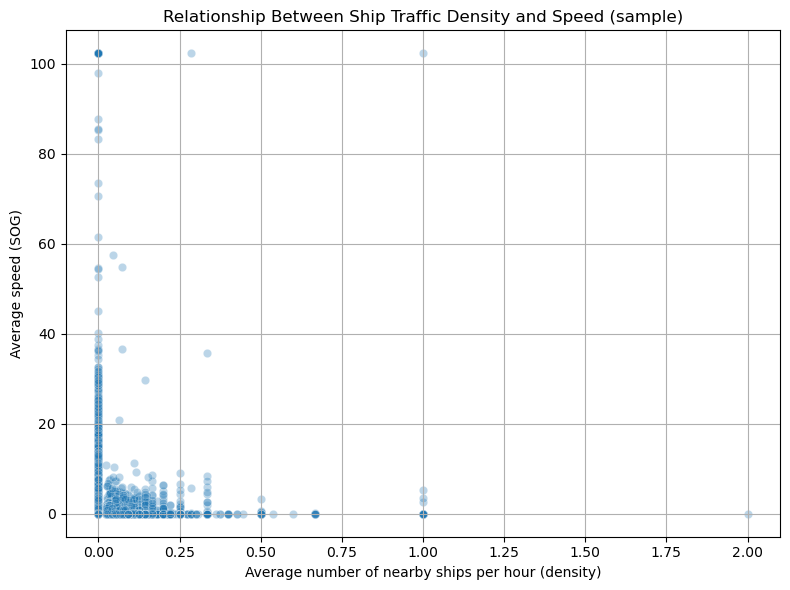

In [24]:
density_clean = (
    density_by_hour_all
    .filter(F.col("avg_speed").isNotNull() & F.col("avg_density").isNotNull())
)

# 2) Sample a manageable fraction (tune fraction if needed)
plot_sample = density_clean.sample(
    withReplacement=False,
    fraction=0.002,   # 0.2% of rows – adjust up/down if too sparse/heavy
    seed=42
)

# 3) Bring to pandas for plotting
pdf = plot_sample.toPandas()

# 4) Scatterplot: nearby ships vs speed (per hour)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pdf, x="avg_density", y="avg_speed", alpha=0.3)
plt.xlabel("Average number of nearby ships per hour (density)")
plt.ylabel("Average speed (SOG)")
plt.title("Relationship Between Ship Traffic Density and Speed (sample)")
plt.grid(True)
plt.tight_layout()
plt.show()

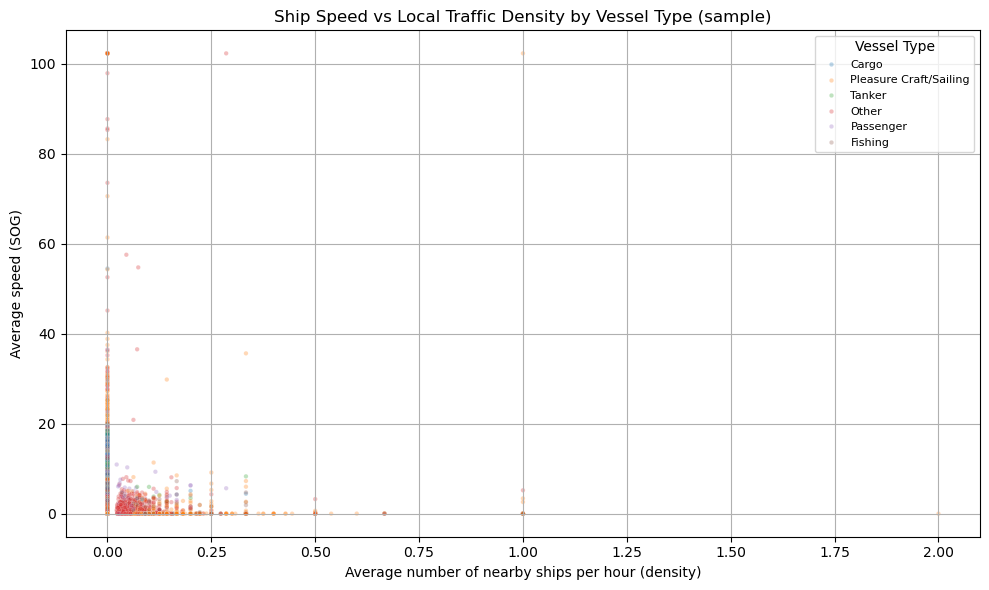

In [25]:
# pdf already exists from above and includes MMSI, avg_speed, avg_density
# merge in vessel type info (assuming you have ship_type_dim: MMSI + VesselTypeLabel)

ship_type_dim = (
    cleaned_ships
    .select("MMSI", "VesselTypeLabel")
    .dropDuplicates(["MMSI"])
)

ship_type_dim_pd = ship_type_dim.select("MMSI", "VesselTypeLabel").toPandas()

pdf = pdf.merge(ship_type_dim_pd, on="MMSI", how="left")

def map_vessel_type(code):
    try:
        c = float(code)
    except (TypeError, ValueError):
        return "Other"
    if 60 <= c < 70:
        return "Passenger"
    elif 70 <= c < 80:
        return "Cargo"
    elif 80 <= c < 90:
        return "Tanker"
    elif c == 30:
        return "Fishing"
    elif 36 <= c <= 37:
        return "Pleasure Craft/Sailing"
    else:
        return "Other"

pdf["VesselTypeGroup"] = pdf["VesselTypeLabel"].apply(map_vessel_type)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pdf,
    x="avg_density",
    y="avg_speed",
    hue="VesselTypeGroup",
    alpha=0.3,
    s=10,
)
plt.xlabel("Average number of nearby ships per hour (density)")
plt.ylabel("Average speed (SOG)")
plt.title("Ship Speed vs Local Traffic Density by Vessel Type (sample)")
plt.legend(title="Vessel Type", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()